---
authors: Freek Pols
updated: December 3, 2025
---

# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

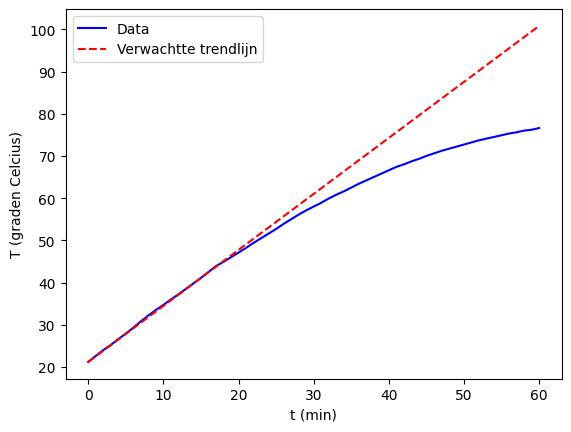

In [50]:
m_maatbeker = 0.8208 #kg
m_maatbeker_vol_start = 1.2929 #kg
m_maatbeker_vol_eind = 1.2749 #kg

Data = pd.read_csv('tempmetingen.csv', delimiter=';')

T_data = Data['T (oC)'] #deg Celsius
t = Data['t (min)'] #min

Geschatte_verwachtte_helling = (T_data[15] - T_data[0])/(t[15] - t[0])   #Het is bekend dat het verband tussen temperatuurstijging en toegevoerde warmte lineair is.

Verwachtte_T_data = Geschatte_verwachtte_helling*t + T_data[0]

plt.figure()
plt.xlabel('t (min)')
plt.ylabel('T (graden Celcius)')
plt.plot(t, T_data, 'b-', label='Data')
plt.plot(t, Verwachtte_T_data, 'r--', label='Verwachtte trendlijn')
plt.legend()
plt.show()


In [52]:
Specifieke_verdampingswarmte_water = 2257 #kJ/kg  #aanname na googelen
v_water = 0.001002 #m^3/kg na interpoleren
V_water_begin = v_water*(m_maatbeker_vol_start - m_maatbeker)  #m^3
c_water = 4.20 #kJ/kg*K  #+- ongeveer 0.3 kJ/kg*K na googelen

#De verwachtte trendlijn geeft een lineair verband tussen toegevoegde warmte en de temperatuur als het water niet zou verdampen. (Is de aanname)

dT_verwacht = Verwachtte_T_data[59] - T_data[0]

dQ = dT_verwacht*(m_maatbeker_vol_start - m_maatbeker)*c_water  #kJ     Dit is zonder verdamping berekend aan de hand van de trendlijn.

m_water_eind = m_maatbeker_vol_eind - m_maatbeker
dm_water = m_maatbeker_vol_start - m_maatbeker - m_water_eind

dQ_real = Specifieke_verdampingswarmte_water*dm_water + m_water_eind*(T_data[59] - T_data[0])*c_water  #kJ   Toegevoegde warmte berekend aan de hand van hoeveelheid verdampt water en de specifieke verdampingswarmte

print('dQ aan de hand van de trendlijn is', f"{dQ:.2f}kJ", 'en dQ aan de hand van verdwenen water is', f"{dQ_real:.2f}kJ")

Afwijking_procent = abs(100*(dQ_real - dQ)/dQ)

print('Trendlijn dQ afwijking van verdwenen water dQ in percentage is', f"{Afwijking_procent:.2f}%")

dQ aan de hand van de trendlijn is 155.20kJ en dQ aan de hand van verdwenen water is 145.52kJ
Trendlijn dQ afwijking van verdwenen water dQ in percentage is 6.24%


Deze waarden komen redelijk overeen, dus het is waarschijnlijk verdamping.